# IBM HR Employee Attrition 

**Dataset:** IBM HR Analytics Employee Attrition and Performance  
**Goal:** Predict which employees are likely to leave the company  

## Imports & Setup

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
RANDOM_STATE = 42  

# Set seaborn style for clean, professional plots
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
import joblib


## Load & Inspect Data

In [83]:
df = pd.read_csv('/kaggle/input/datasets/aryanmdev/tech-hiring-and-la/IBM-HR-Analytics-Employee-Attrition-and-Performance.csv')
df_raw = df.copy()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [84]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [86]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [87]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

No missing values


Attrition
No     1233
Yes     237
Name: count, dtype: int64
Ratio (No/Yes): 5.2


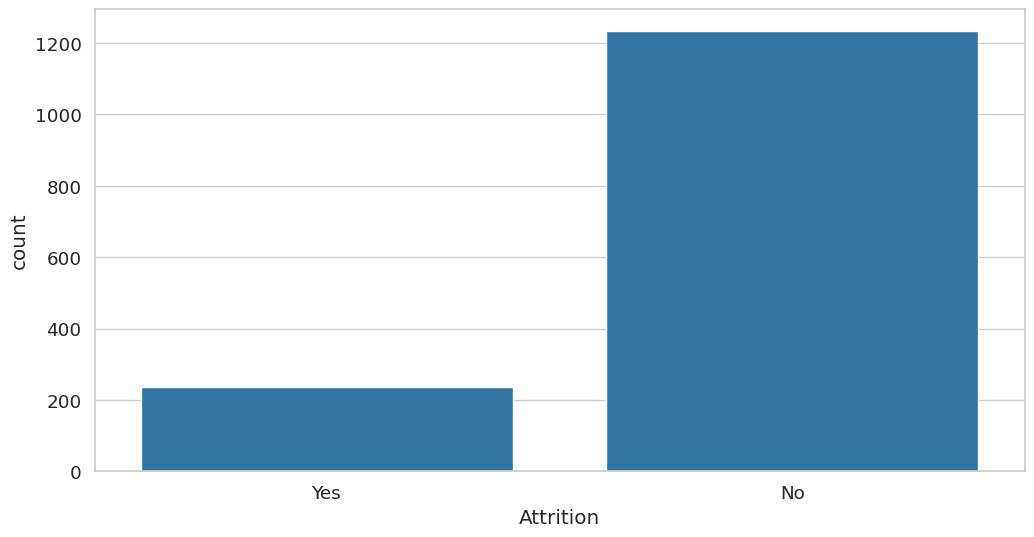

In [88]:
counts = df['Attrition'].value_counts()

print(counts)
print(f"Ratio (No/Yes): {counts['No'] / counts['Yes']:.1f}")

sns.countplot(data=df, x='Attrition')
plt.show()

**Observation**
The dataset is heavily imbalanced : ~84% employees stay (No) vs ~16% leave (Yes). 

## Data Preprocessing

In [89]:
cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols, errors='ignore')

print(df.shape)

(1470, 31)


In [90]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [91]:
ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'WorkLifeBalance', 'JobLevel', 'StockOptionLevel'
]

print(df[ordinal_cols].nunique())

Education                   5
EnvironmentSatisfaction     4
JobInvolvement              4
JobSatisfaction             4
PerformanceRating           2
RelationshipSatisfaction    4
WorkLifeBalance             4
JobLevel                    5
StockOptionLevel            4
dtype: int64


In [92]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print(df[['Gender', 'OverTime']].value_counts())

Gender  OverTime
1       0           646
0       0           408
1       1           236
0       1           180
Name: count, dtype: int64


In [93]:
nominal_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(df.shape)

(1470, 45)


In [94]:
print(df.shape)
print(df.dtypes)

(1470, 45)
Age                                  int64
Attrition                            int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
Gender                               int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtCompany                       int64


## Outlier Detection

We use the **IQR (Interquartile Range) method** to detect outliers:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 - Q1
- Outliers are values below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR`

We'll **flag** outliers but NOT remove them — some "outliers" might be real high-earners or long-tenured employees.

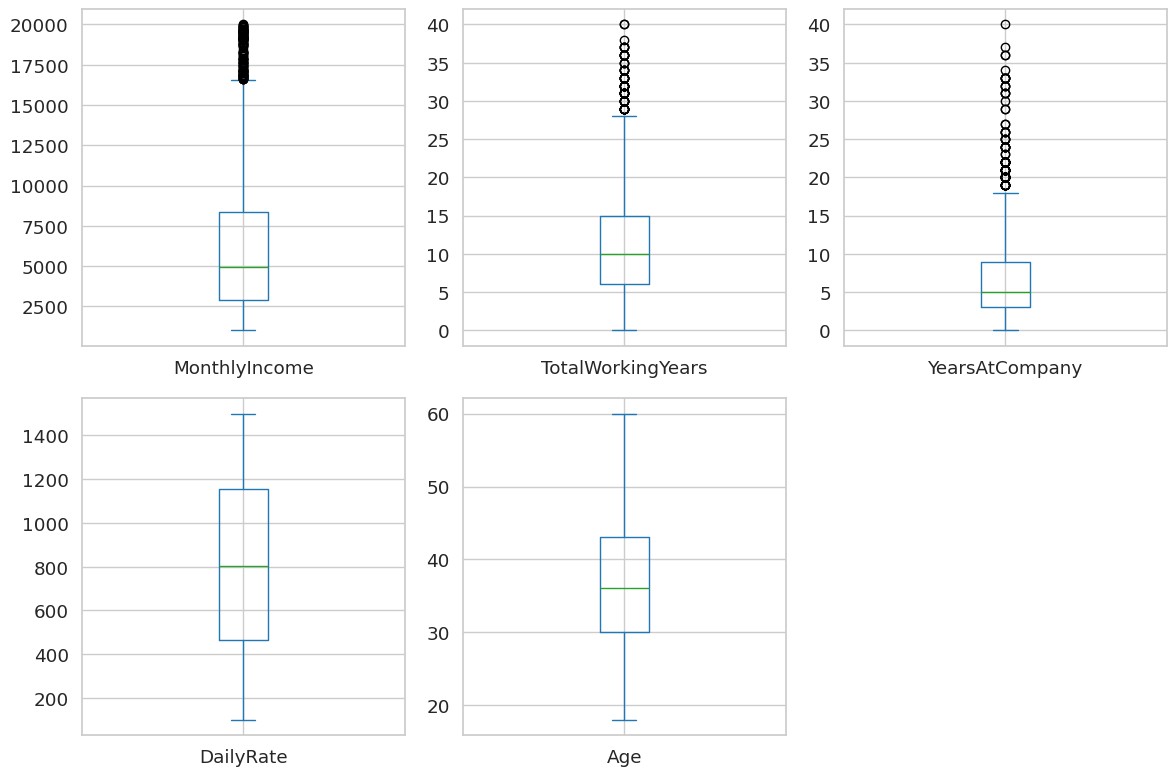

In [95]:
cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DailyRate', 'Age']

df[cols].plot(
    kind='box',
    subplots=True,
    layout=(2, 3),  
    figsize=(12, 8)  
)

plt.tight_layout()
plt.show()

In [96]:
cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DailyRate', 'Age']

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).sum()

print(outliers)

MonthlyIncome        114
TotalWorkingYears     63
YearsAtCompany       104
DailyRate              0
Age                    0
dtype: int64


### Outlier Decision
- **MonthlyIncome** and **TotalWorkingYears** have noticeable outliers (senior employees / executives)
- These are **valid data points**, not errors — removing them would bias the model
- Tree-based models (XGBoost, CatBoost) are naturally robust to outliers
- For linear models, StandardScaler helps reduce outlier impact

## Exploratory Data Analysis (EDA)

In [97]:
def plot_attrition(data, col, numeric=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # LEFT: distribution
    if numeric:
        sns.histplot(data=data, x=col, hue='Attrition', ax=axes[0])
    else:
        sns.countplot(data=data, x=col, ax=axes[0])
        axes[0].tick_params(axis='x', rotation=45)

    # RIGHT: attrition rate
    if numeric:
        bins = pd.qcut(data[col], q=5, duplicates='drop')
        rate = data.groupby(bins)['Attrition'].mean()
    else:
        rate = data.groupby(col)['Attrition'].mean()

    rate.plot(kind='bar', ax=axes[1])
    axes[1].set_ylabel('Attrition Rate')

    plt.tight_layout()
    plt.show()

In [98]:
# We use df_raw for readable EDA charts (before encoding)
# But drop the useless columns
df_eda = df_raw.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], errors='ignore')
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

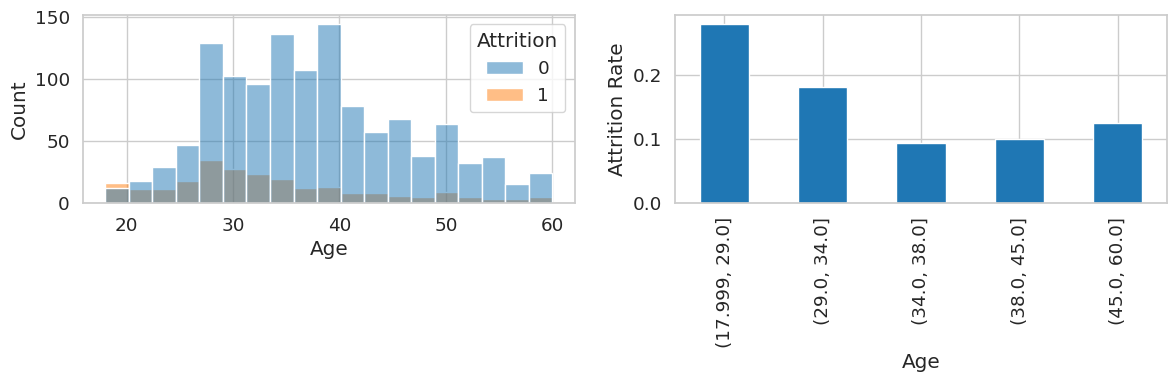

In [99]:
plot_attrition(df_eda, 'Age', numeric=True)

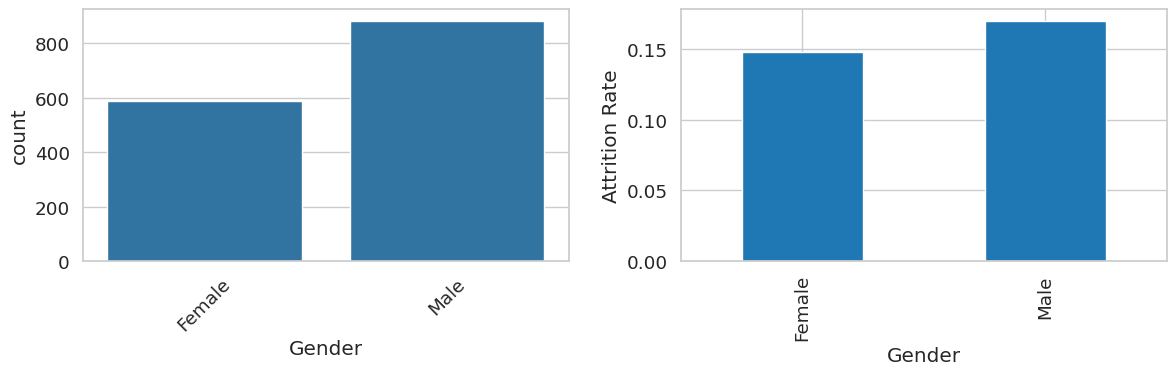

In [100]:
plot_attrition(df_eda, 'Gender')

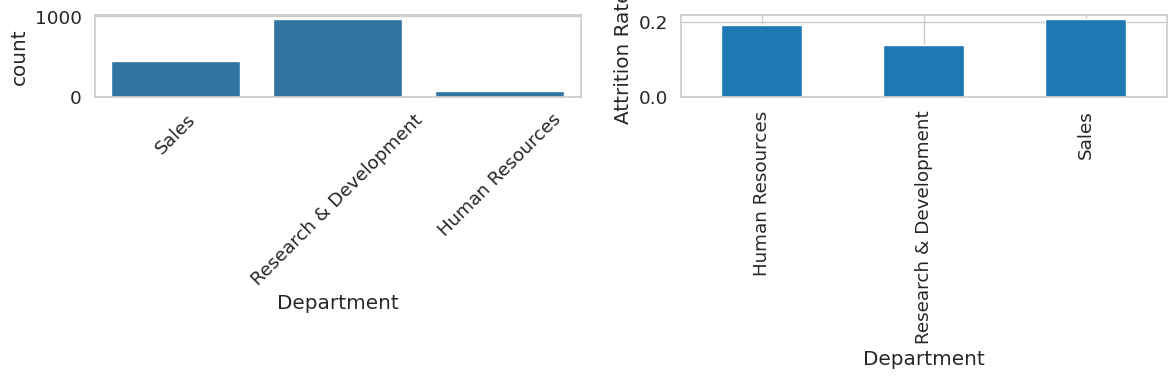

In [101]:
plot_attrition(df_eda, 'Department')

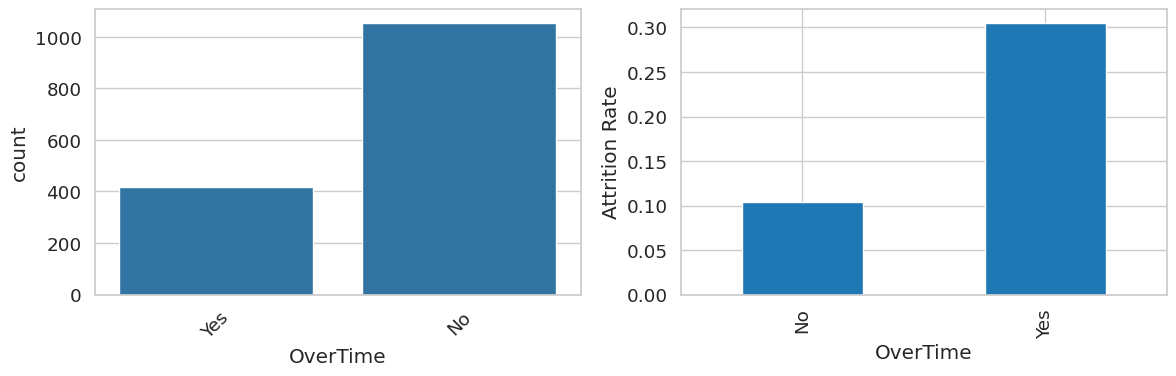

In [102]:
plot_attrition(df_eda, 'OverTime')

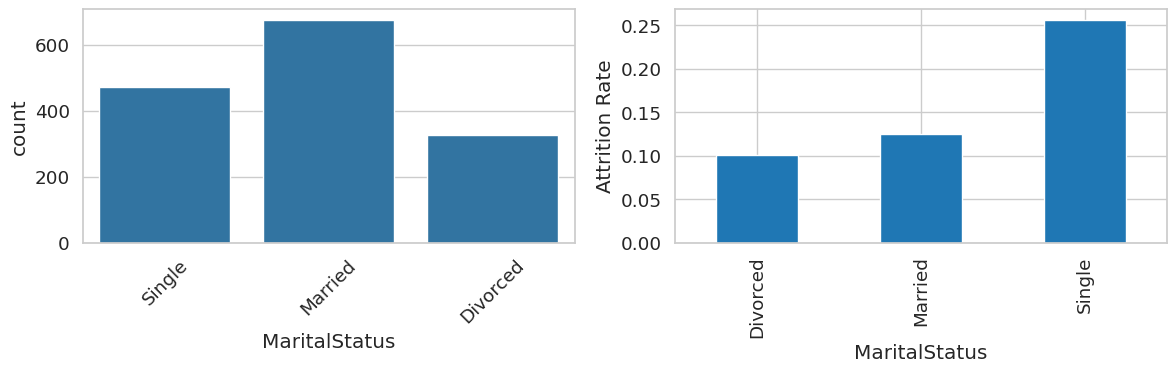

In [103]:
plot_attrition(df_eda, 'MaritalStatus')

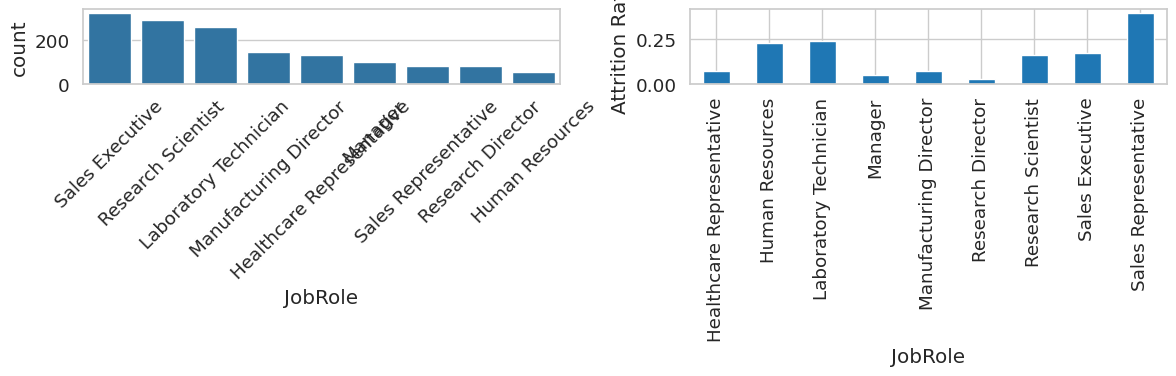

In [104]:
plot_attrition(df_eda, 'JobRole')

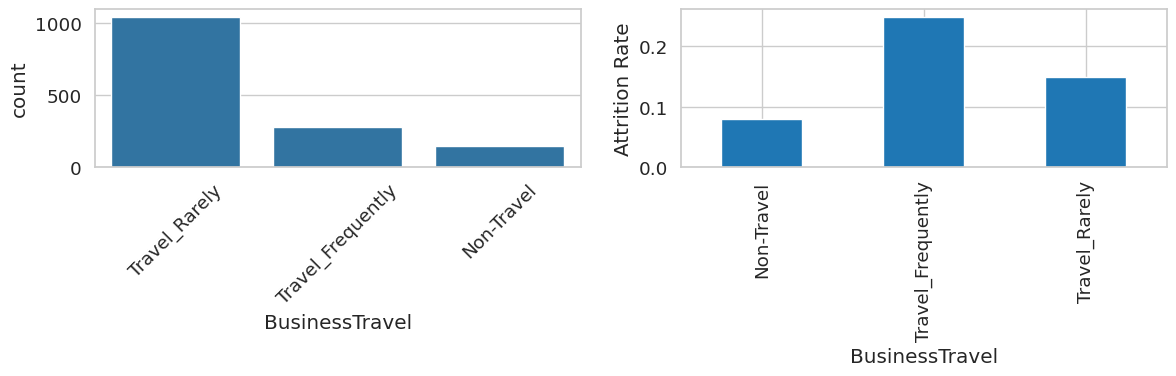

In [105]:
plot_attrition(df_eda, 'BusinessTravel')

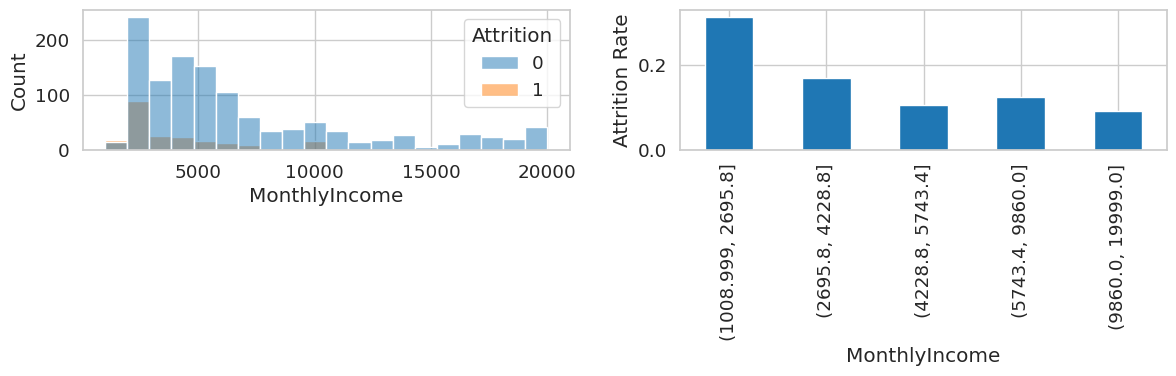

In [106]:
plot_attrition(df_eda, 'MonthlyIncome', numeric=True)

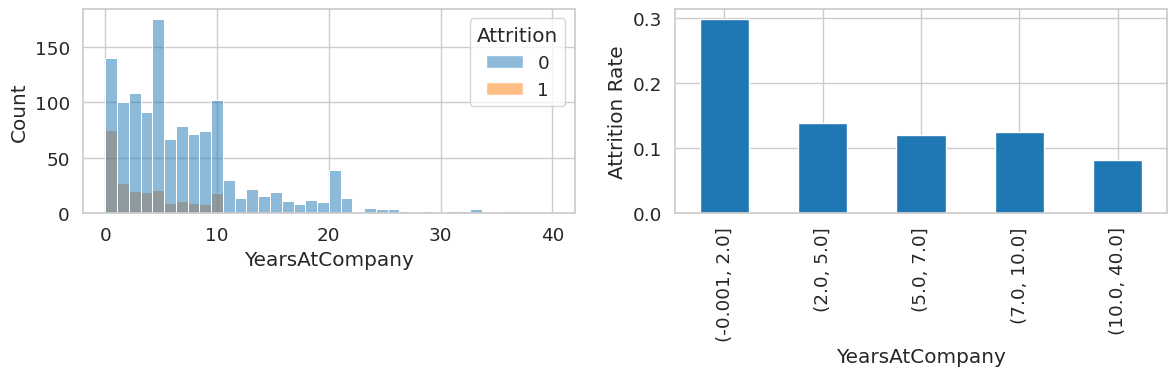

In [107]:
plot_attrition(df_eda, 'YearsAtCompany', numeric=True)

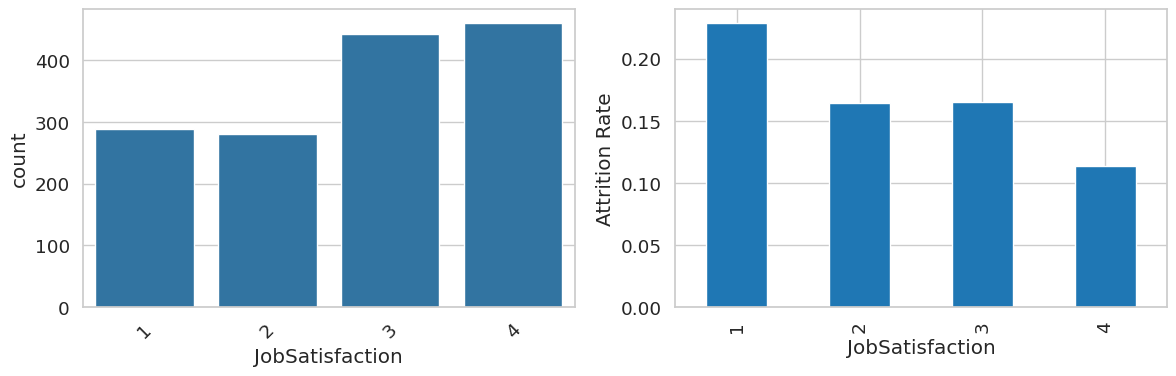

In [108]:
plot_attrition(df_eda, 'JobSatisfaction')

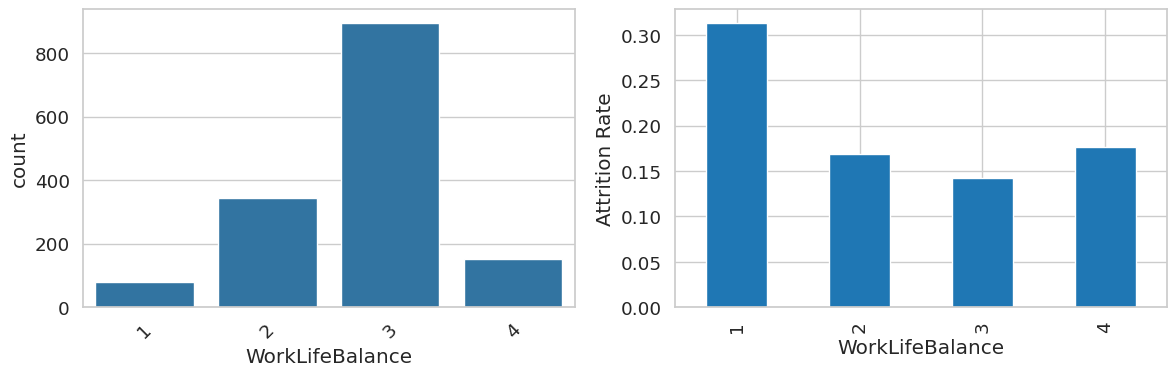

In [109]:
plot_attrition(df_eda, 'WorkLifeBalance')

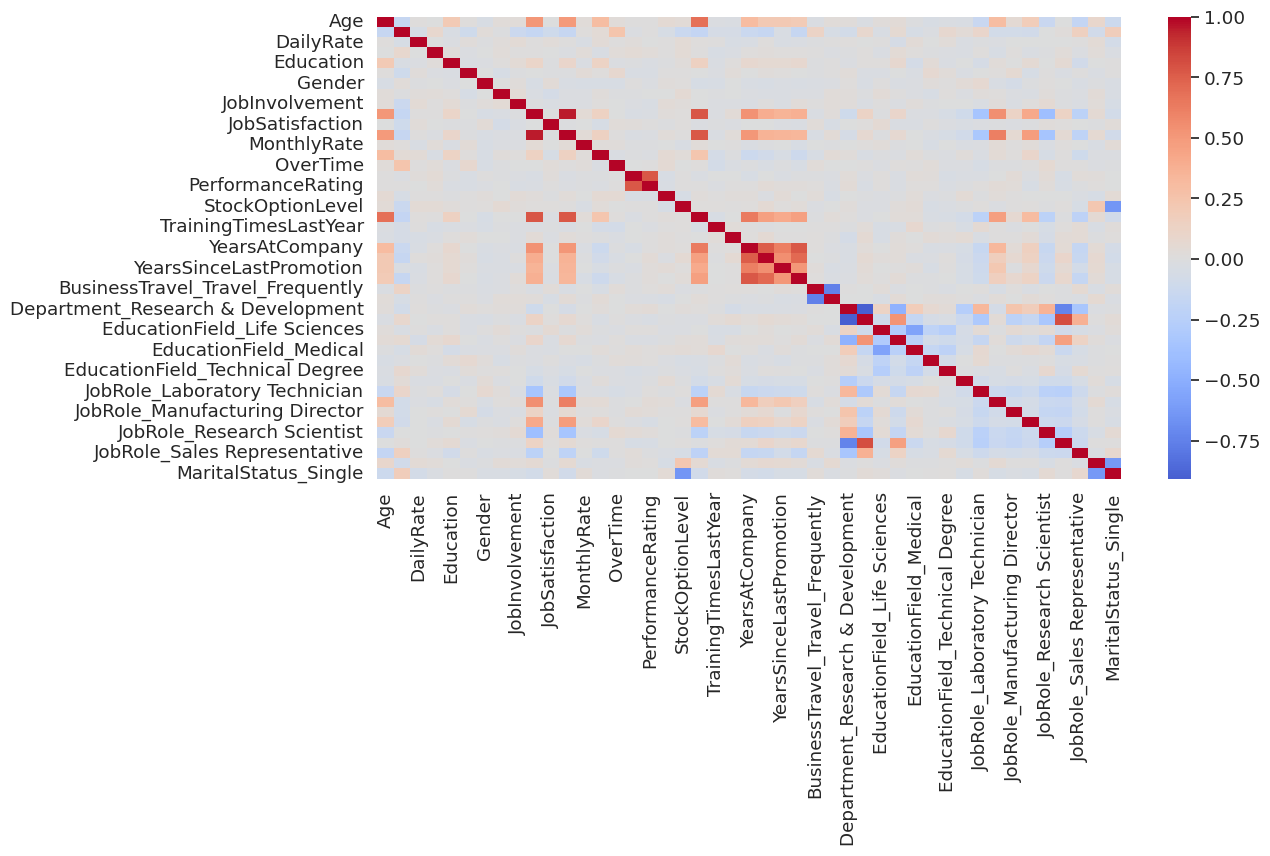

In [110]:
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [111]:
corr = df.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

print(corr.head(10))

OverTime                        0.246118
MaritalStatus_Single            0.175419
TotalWorkingYears              -0.171063
JobLevel                       -0.169105
YearsInCurrentRole             -0.160545
MonthlyIncome                  -0.159840
Age                            -0.159205
JobRole_Sales Representative    0.157234
YearsWithCurrManager           -0.156199
StockOptionLevel               -0.137145
Name: Attrition, dtype: float64


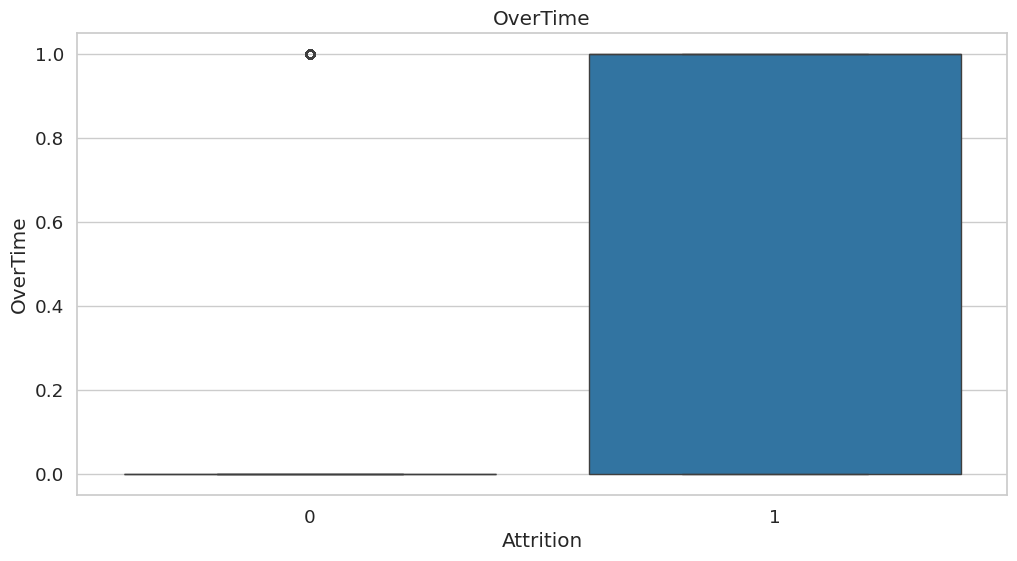

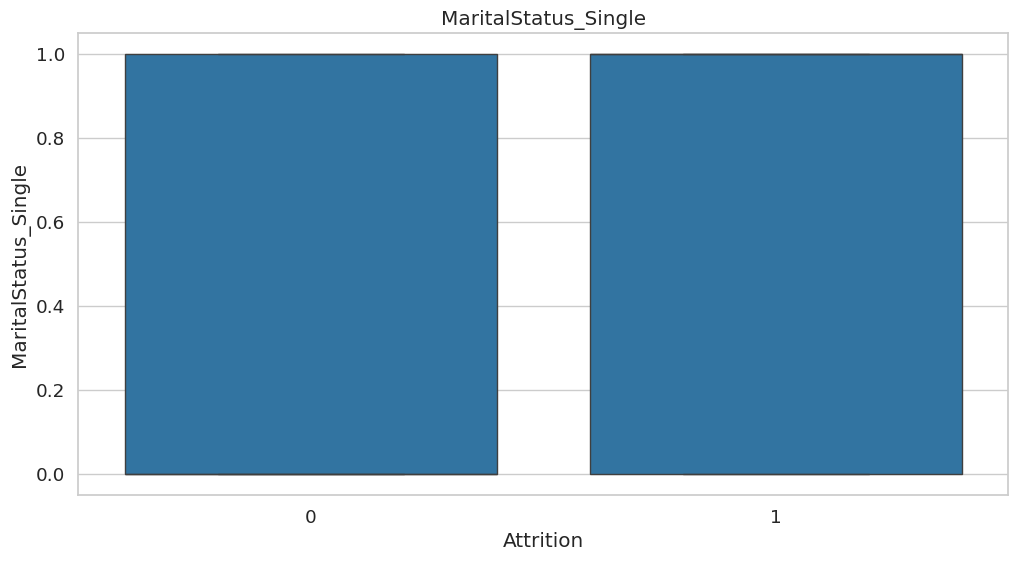

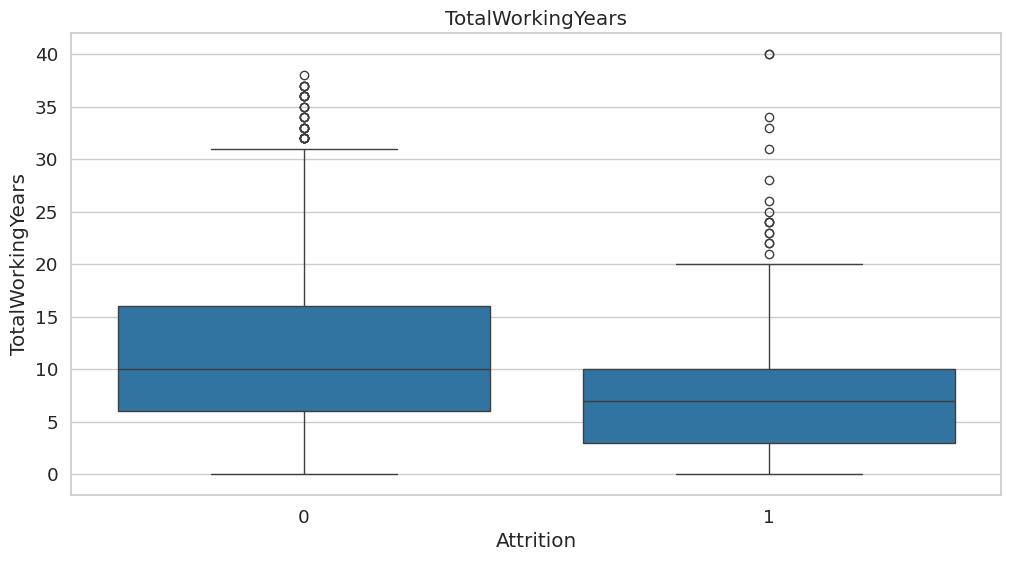

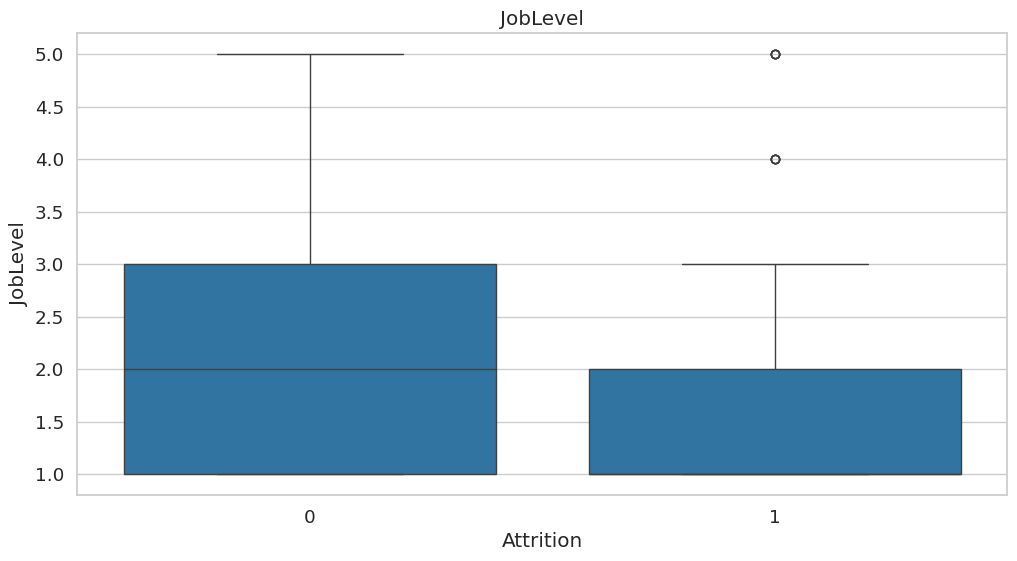

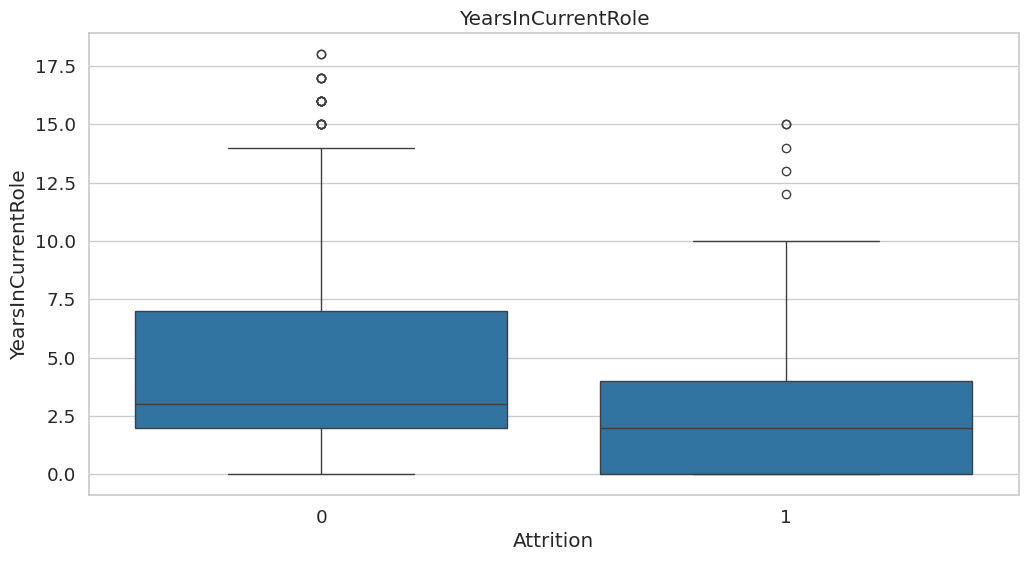

In [112]:
cols = corr.head(5).index

for col in cols:
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.title(col)
    plt.show()

## Statistical Analysis (ANOVA & Chi-Square Tests)

In [113]:
from scipy.stats import f_oneway

numerical_cols = df_eda.select_dtypes(include=[np.number]).columns.drop('Attrition')

anova_results = []
for col in numerical_cols:
    # Split feature values by Attrition group
    group_stay = df_eda[df_eda['Attrition'] == 0][col]
    group_leave = df_eda[df_eda['Attrition'] == 1][col]
    
    # Run one-way ANOVA
    f_score, p_value = f_oneway(group_stay, group_leave)
    anova_results.append({'Feature': col, 'F_Score': f_score, 'P_Value': p_value})

anova_df = pd.DataFrame(anova_results).sort_values('F_Score', ascending=False)

print("ANOVA Test Results (Numerical Features vs Attrition)")
print("=" * 65)
for _, row in anova_df.iterrows():
    sig = "\u2705 Significant" if row['P_Value'] < 0.05 else "\u274c Not Significant"
    print(f"  {row['Feature']:30s}  F={row['F_Score']:8.2f}  p={row['P_Value']:.6f}  {sig}")

ANOVA Test Results (Numerical Features vs Attrition)
  TotalWorkingYears               F=   44.25  p=0.000000  ✅ Significant
  JobLevel                        F=   43.22  p=0.000000  ✅ Significant
  YearsInCurrentRole              F=   38.84  p=0.000000  ✅ Significant
  MonthlyIncome                   F=   38.49  p=0.000000  ✅ Significant
  Age                             F=   38.18  p=0.000000  ✅ Significant
  YearsWithCurrManager            F=   36.71  p=0.000000  ✅ Significant
  StockOptionLevel                F=   28.14  p=0.000000  ✅ Significant
  YearsAtCompany                  F=   27.00  p=0.000000  ✅ Significant
  JobInvolvement                  F=   25.24  p=0.000001  ✅ Significant
  JobSatisfaction                 F=   15.89  p=0.000070  ✅ Significant
  EnvironmentSatisfaction         F=   15.86  p=0.000072  ✅ Significant
  DistanceFromHome                F=    8.97  p=0.002793  ✅ Significant
  WorkLifeBalance                 F=    6.03  p=0.014211  ✅ Significant
  TrainingT

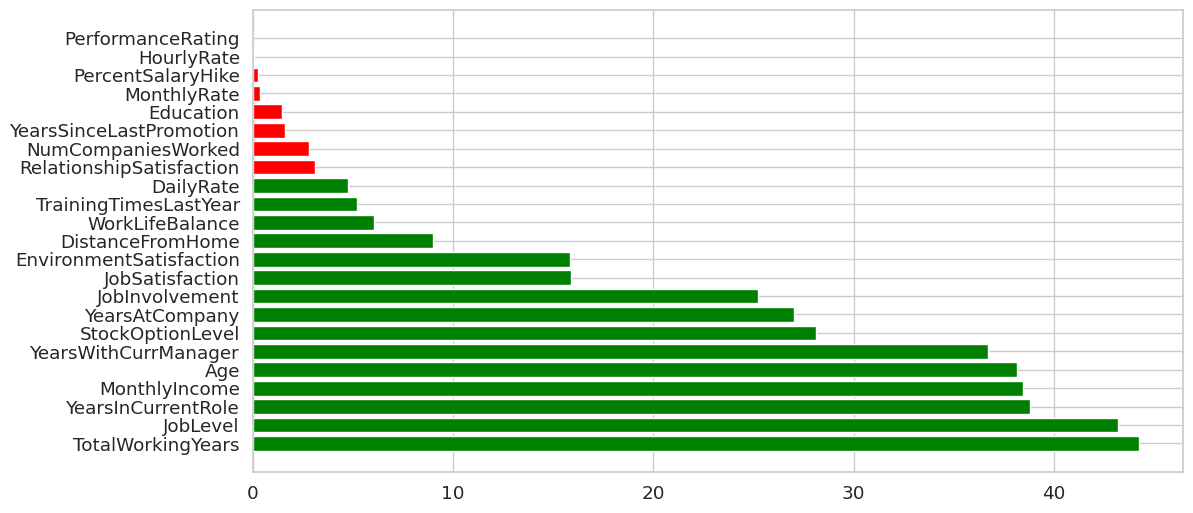

In [114]:
fig, ax = plt.subplots()

colors = ['green' if p < 0.05 else 'red' for p in anova_df['P_Value']]
ax.barh(anova_df['Feature'], anova_df['F_Score'], color=colors)

plt.show()

In [115]:
from scipy.stats import chi2_contingency

categorical_test_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                         'JobRole', 'MaritalStatus', 'OverTime']

chi2_results = []
for col in categorical_test_cols:
    contingency = pd.crosstab(df_eda[col], df_eda['Attrition'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({'Feature': col, 'Chi2_Stat': chi2_stat, 'P_Value': p_value, 'DoF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2_Stat', ascending=False)

print(chi2_df)

          Feature  Chi2_Stat       P_Value  DoF
6        OverTime  87.564294  8.158424e-21    1
4         JobRole  86.190254  2.752482e-15    8
5   MaritalStatus  46.163677  9.455511e-11    2
0  BusinessTravel  24.182414  5.608614e-06    2
2  EducationField  16.024674  6.773980e-03    5
1      Department  10.796007  4.525607e-03    2
3          Gender   1.116967  2.905724e-01    1


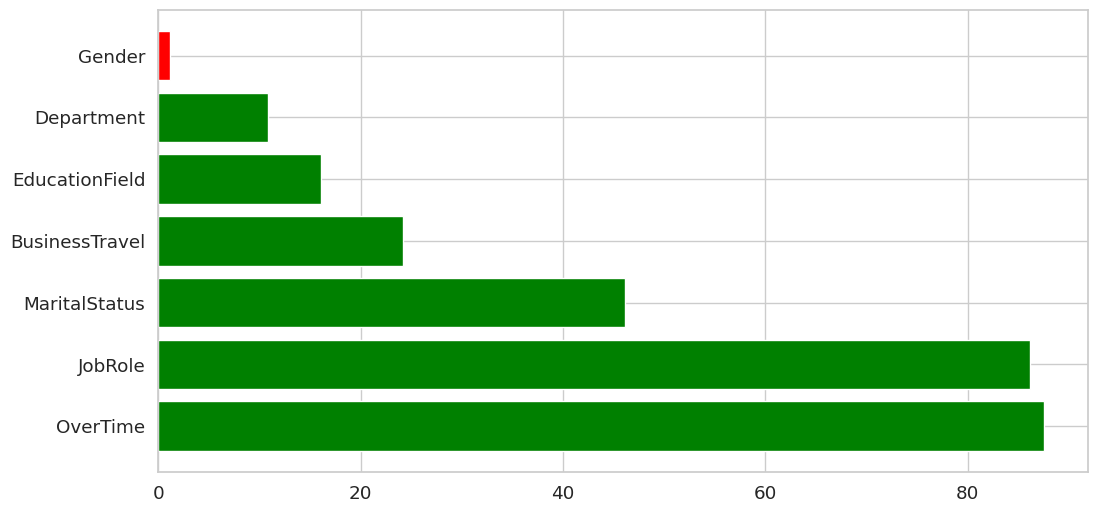

In [116]:
fig, ax = plt.subplots()

colors = ['green' if p < 0.05 else 'red' for p in chi2_df['P_Value']]
ax.barh(chi2_df['Feature'], chi2_df['Chi2_Stat'], color=colors)

plt.show()

## Feature Engineering (New Columns)

In [117]:
df['IncomePerYear'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

df['PromotionLag'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']

df['TenureRatio'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1)

df['SatisfactionScore'] = (
    df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['WorkLifeBalance']
) / 3

df['IsOverworked'] = ((df['OverTime'] == 1) & (df['WorkLifeBalance'] <= 2)).astype(int)

df['ExperienceLevel'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[0, 2, 5, 10, 20, 50],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
).astype(int)

print(df.shape)

(1470, 51)


IncomePerYear        0.097731
PromotionLag        -0.147895
TenureRatio         -0.157625
SatisfactionScore   -0.159721
IsOverworked         0.143301
ExperienceLevel     -0.209454
dtype: float64


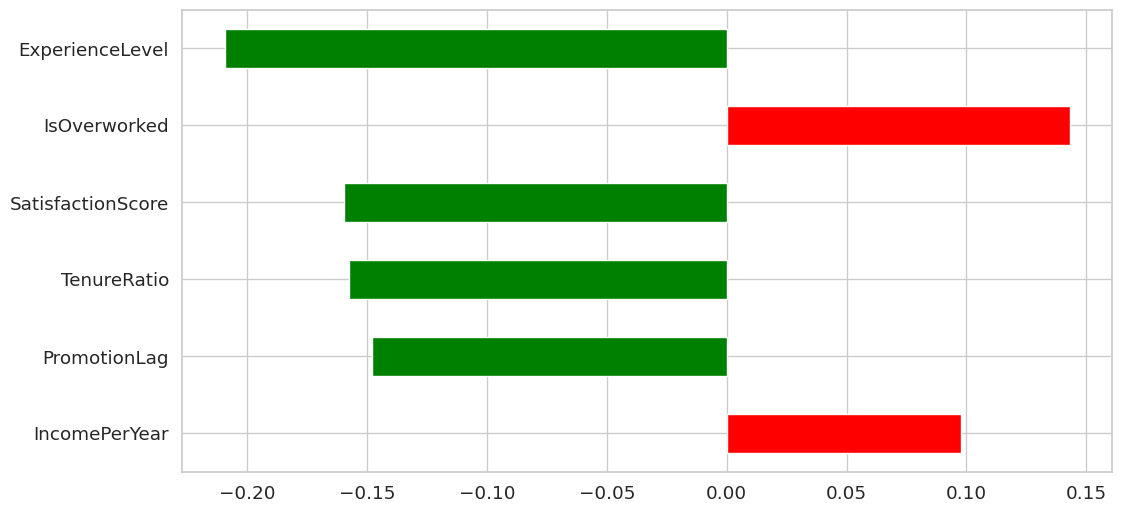

In [118]:
new_features = ['IncomePerYear', 'PromotionLag', 'TenureRatio',
                'SatisfactionScore', 'IsOverworked', 'ExperienceLevel']

new_corr = df[new_features].corrwith(df['Attrition'])

print(new_corr)

fig, ax = plt.subplots()
colors = ['red' if v > 0 else 'green' for v in new_corr.values]
new_corr.plot(kind='barh', color=colors, ax=ax)

plt.show()

## Train/Test Split

I split the data 80/20 and use stratification to ensure both train and test sets  
have the same proportion of attrition (Yes/No) crucial for imbalanced datasets.

In [119]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")

Features (X): (1470, 50)
Target  (y): (1470,)


In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [121]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled.shape, X_test_scaled.shape)

(1176, 50) (294, 50)


## Cross-Validation Setup
  
**5-Fold Stratified Cross-Validation** trains 5 models on different splits and averages the results,  


In [122]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cross_val_report(model, X, y, model_name):
    scoring = ['accuracy', 'f1', 'roc_auc']
    cv_results = cross_validate(model, X, y, cv=cv_strategy,
                                scoring=scoring, return_train_score=False)
    
    result_dict = {}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        print(metric, scores.mean(), scores.std())
        result_dict[metric] = scores.mean()
    
    return result_dict

## Baseline Model: Logistic Regression

In [123]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(accuracy_score(y_test, y_pred_lr))
print(roc_auc_score(y_test, y_prob_lr))
print(f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.7619047619047619
0.8107502799552072
0.46153846153846156
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.36      0.64      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.76      0.79       294



In [124]:
lr_cv_scores = cross_val_report(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    X_train_scaled, y_train, "Logistic Regression"
)

accuracy 0.7610205553552108 0.021062423006344946
f1 0.49736399826588507 0.019416924018633985
roc_auc 0.8295830331096161 0.025409409667114656


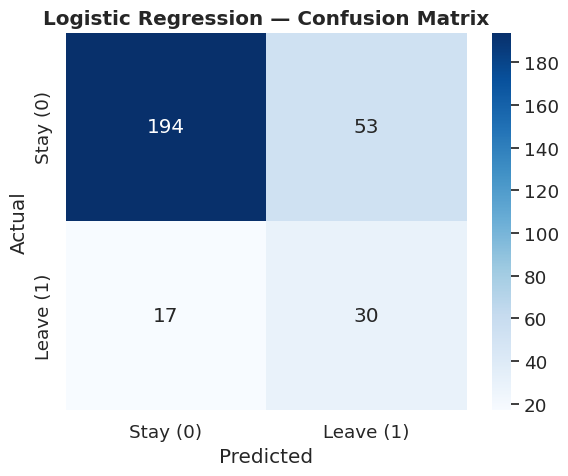

In [125]:
# ===== CONFUSION MATRIX HEATMAP =====
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stay (0)', 'Leave (1)'],
            yticklabels=['Stay (0)', 'Leave (1)'])
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

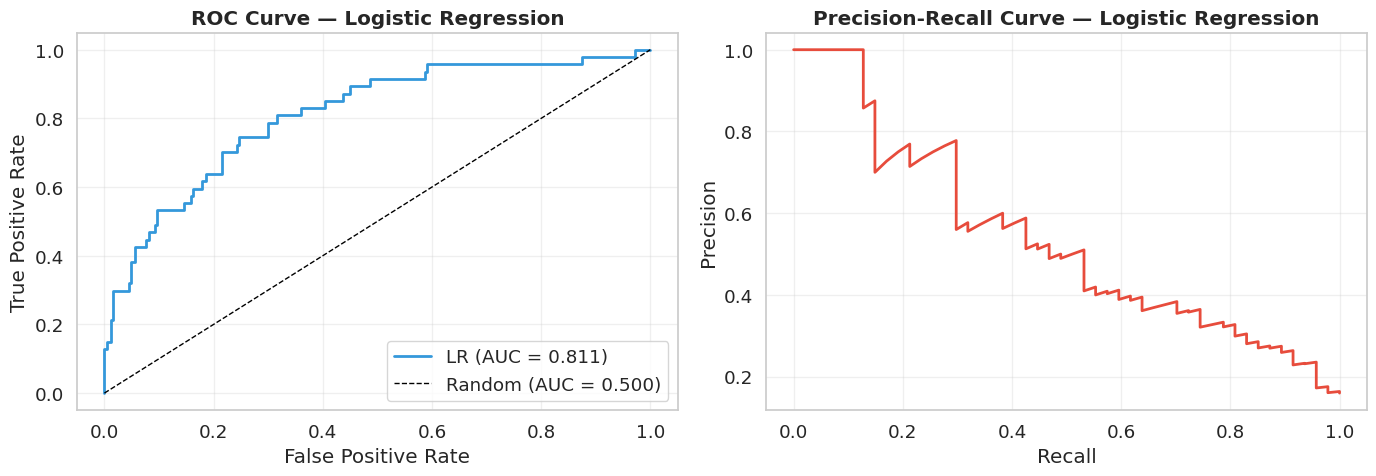

In [126]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2, label=f'LR (AUC = {auc_lr:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax1.set_title('ROC Curve — Logistic Regression', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)


precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ax2.plot(recall_lr, precision_lr, color='#e74c3c', linewidth=2)
ax2.set_title('Precision-Recall Curve — Logistic Regression', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Class Imbalance: Detection & Fix

In [127]:
# ===== 9A: PROVE THE PROBLEM WITH A DUMMY CLASSIFIER =====
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

dummy_acc = accuracy_score(y_test, y_pred_dummy)
print(f"Dummy Classifier (always predicts 'No'):")
print(f"  Accuracy: {dummy_acc:.4f} ({dummy_acc*100:.1f}%)")
print(f"  F1 Score: {f1_score(y_test, y_pred_dummy):.4f}")
print(f"\n→ The dummy gets {dummy_acc*100:.1f}% accuracy by learning NOTHING!")
print(f"→ Our LR model must beat this to be useful.")

Dummy Classifier (always predicts 'No'):
  Accuracy: 0.8401 (84.0%)
  F1 Score: 0.0000

→ The dummy gets 84.0% accuracy by learning NOTHING!
→ Our LR model must beat this to be useful.


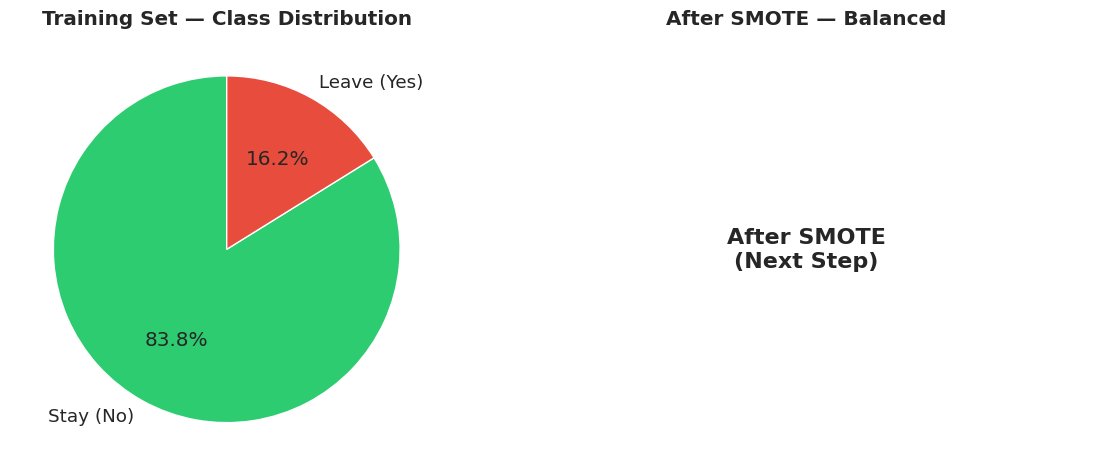

In [128]:
# ===== CLASS DISTRIBUTION PIE CHART =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Training set
y_train.value_counts().plot.pie(
    labels=['Stay (No)', 'Leave (Yes)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    ax=ax1, startangle=90
)
ax1.set_title('Training Set — Class Distribution', fontweight='bold')
ax1.set_ylabel('')

# After we'll show SMOTE — for now just show the imbalance
ax2.text(0.5, 0.5, 'After SMOTE\n(Next Step)', ha='center', va='center',
         fontsize=16, fontweight='bold', transform=ax2.transAxes)
ax2.set_title('After SMOTE — Balanced', fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

### Fixing with SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** creates **synthetic** samples  
of the minority class — it doesn't just duplicate existing rows!

It works by:
1. Picking a minority sample
2. Finding its k nearest neighbors (also minority)
3. Creating a new point somewhere between them

This gives the model more diverse examples to learn from.

In [129]:
# ===== 9B: APPLY SMOTE TO BALANCE THE TRAINING DATA =====
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Class 0 (Stay):  {(y_train == 0).sum()}")
print(f"  Class 1 (Leave): {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"  Class 0 (Stay):  {(y_train_sm == 0).sum()}")
print(f"  Class 1 (Leave): {(y_train_sm == 1).sum()}")

print(f"\n✅ Training set is now balanced! ({len(y_train_sm)} total samples)")

Before SMOTE:
  Class 0 (Stay):  986
  Class 1 (Leave): 190

After SMOTE:
  Class 0 (Stay):  986
  Class 1 (Leave): 986

✅ Training set is now balanced! (1972 total samples)


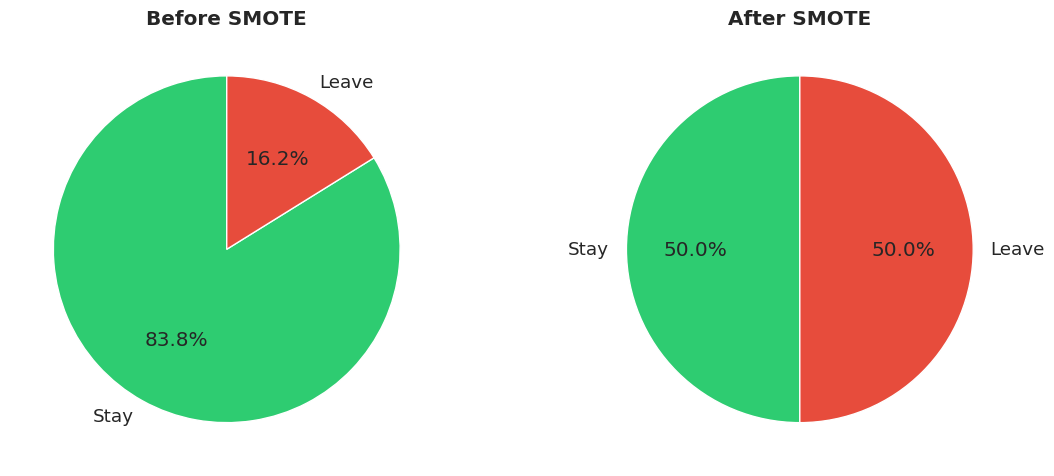

In [130]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


pd.Series(y_train).value_counts().plot.pie(
    labels=['Stay', 'Leave'], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], ax=ax1, startangle=90
)
ax1.set_title('Before SMOTE', fontweight='bold')
ax1.set_ylabel('')


pd.Series(y_train_sm).value_counts().plot.pie(
    labels=['Stay', 'Leave'], autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'], ax=ax2, startangle=90
)
ax2.set_title('After SMOTE', fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

## XGBoost Model

XGBoost is a **gradient boosting** algorithm — it builds trees sequentially,  
where each new tree corrects the errors of the previous ones.

We use `scale_pos_weight` to handle class imbalance directly,  
plus manually tuned hyperparameters (not defaults).

In [131]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (No/Yes): {ratio:.2f}")
print(f"→ We'll give {ratio:.1f}x more weight to 'Yes' (attrition) samples")

Class imbalance ratio (No/Yes): 5.19
→ We'll give 5.2x more weight to 'Yes' (attrition) samples


### Hyperparameter Tuning with RandomizedSearchCV

Instead of guessing parameters, we let **RandomizedSearchCV** search over a grid  
of hyperparameter combinations using cross-validation to find the best ones.

In [132]:
# ===== HYPERPARAMETER TUNING FOR XGBOOST =====
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=RANDOM_STATE

)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_scaled, y_train)

print(f"\n\u2705 Best F1 Score from CV: {xgb_search.best_score_:.4f}")
print(f"Best Parameters:")
for param, value in xgb_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits

✅ Best F1 Score from CV: 0.5366
Best Parameters:
  subsample: 0.7
  n_estimators: 200
  min_child_weight: 3
  max_depth: 6
  learning_rate: 0.1
  colsample_bytree: 0.8


In [133]:
# ===== TRAIN XGBOOST WITH BEST PARAMETERS =====
xgb_model = xgb_search.best_estimator_

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBoost (Tuned) \u2014 Test Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"F1 (Yes):  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_xgb)}")

XGBoost (Tuned) — Test Results
Accuracy:  0.8469
ROC-AUC:   0.7686
F1 (Yes):  0.4156

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.53      0.34      0.42        47

    accuracy                           0.85       294
   macro avg       0.71      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



In [134]:
# ===== CROSS-VALIDATE XGBOOST =====
xgb_cv_scores = cross_val_report(
    xgb_search.best_estimator_,
    X_train_scaled, y_train, "XGBoost (Tuned)"
)

accuracy 0.8656364947710061 0.013703325296273392
f1 0.5146673101588182 0.06868273907573978
roc_auc 0.8070712467987381 0.03526289806698568


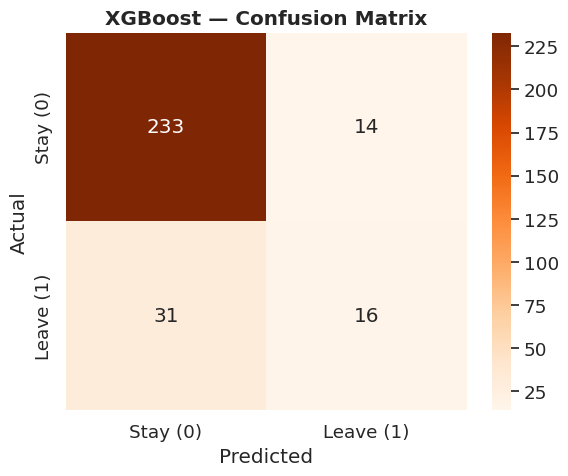

In [135]:
# ===== XGBOOST CONFUSION MATRIX =====
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Stay (0)', 'Leave (1)'],
            yticklabels=['Stay (0)', 'Leave (1)'])
ax.set_title('XGBoost — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

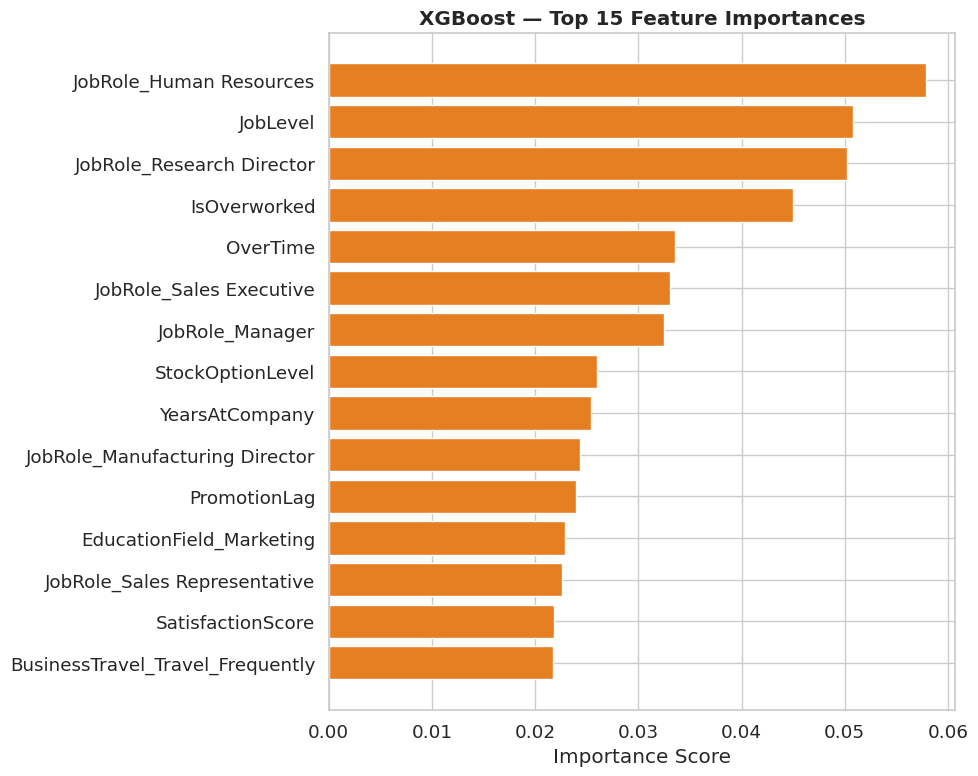

In [136]:
# ===== XGBOOST FEATURE IMPORTANCE (Top 15) =====
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['feature'], feature_importance['importance'], color='#e67e22')
ax.set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

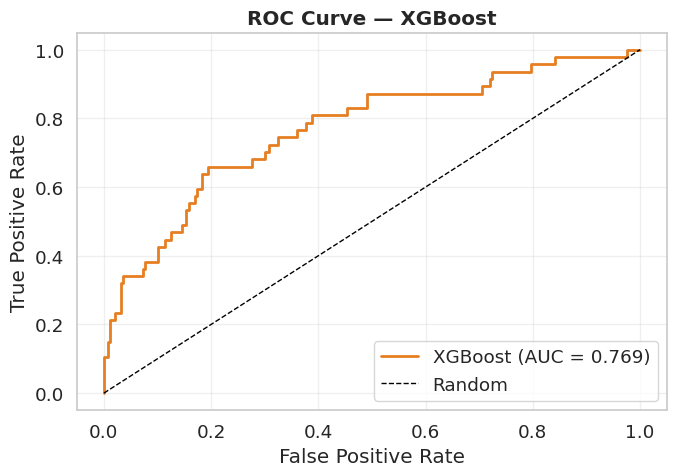

In [137]:
# ===== XGBOOST ROC CURVE =====
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_xgb, tpr_xgb, color='#e67e22', linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC Curve — XGBoost', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## CatBoost Model

CatBoost (Categorical Boosting) is another gradient boosting algorithm from Yandex.  
It handles categorical features natively and often works well with minimal tuning.  
We use `class_weights` to handle imbalance.

In [138]:
# ===== TRAIN CATBOOST =====
cat_model = CatBoostClassifier(
    iterations=300,             # Number of boosting rounds
    depth=4,                    # Tree depth
    learning_rate=0.05,         # Small learning rate
    auto_class_weights='Balanced',   # Weight the minority class higher
    verbose=0,                  # Suppress training output
    random_state=RANDOM_STATE
)
cat_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_test_scaled)
y_prob_cat = cat_model.predict_proba(X_test_scaled)[:, 1]

print("CatBoost — Test Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_cat):.4f}")
print(f"F1 (Yes):  {f1_score(y_test, y_pred_cat):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_cat)}")

CatBoost — Test Results
Accuracy:  0.8265
ROC-AUC:   0.7649
F1 (Yes):  0.4632

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       247
           1       0.46      0.47      0.46        47

    accuracy                           0.83       294
   macro avg       0.68      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294



In [139]:
# ===== CROSS-VALIDATE CATBOOST =====
cat_cv_scores = cross_val_report(
    CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05,
                       auto_class_weights='Balanced', verbose=0, random_state=RANDOM_STATE),
    X_train_scaled, y_train, "CatBoost"
)

accuracy 0.8503173458348361 0.027599660718922142
f1 0.5188024953354826 0.08518352005414183
roc_auc 0.7950281603100198 0.03524342470422972


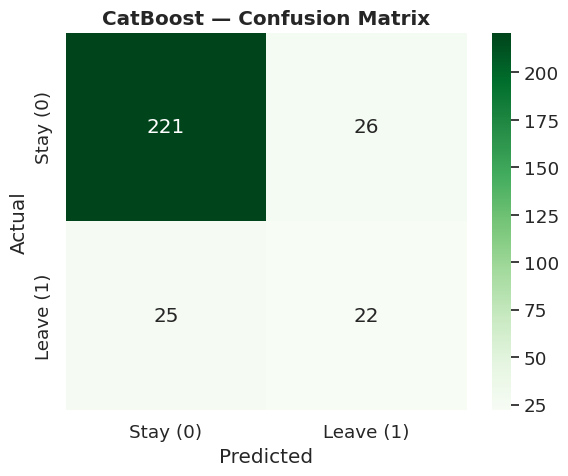

In [140]:
# ===== CATBOOST CONFUSION MATRIX =====
fig, ax = plt.subplots(figsize=(6, 5))
cm_cat = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Stay (0)', 'Leave (1)'],
            yticklabels=['Stay (0)', 'Leave (1)'])
ax.set_title('CatBoost — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

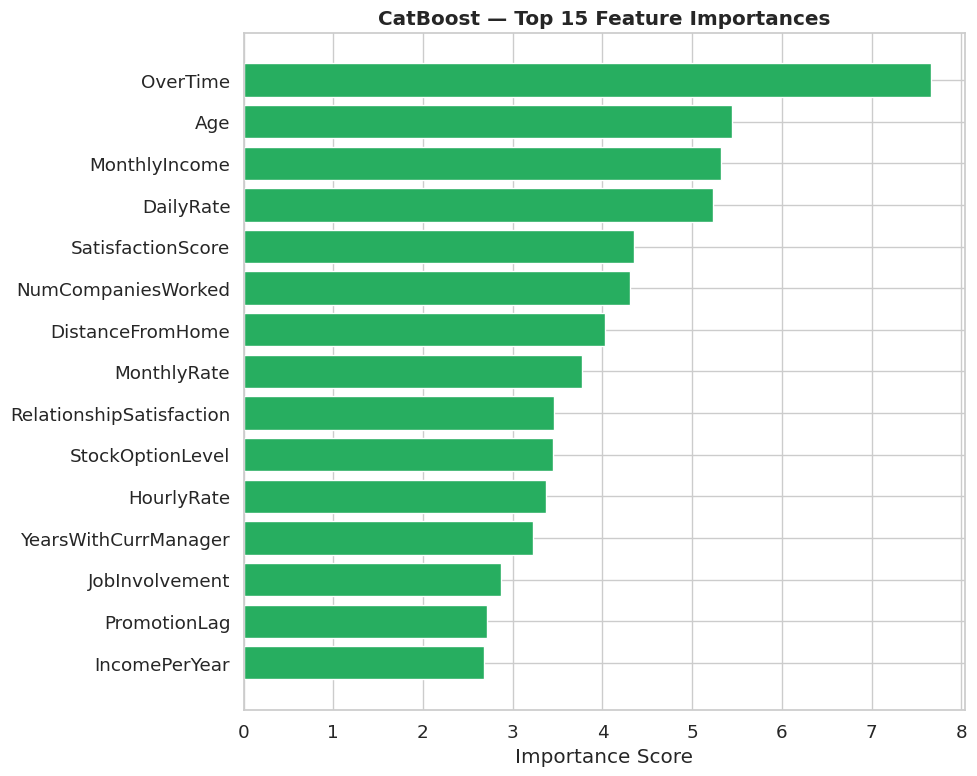

In [141]:
# ===== CATBOOST FEATURE IMPORTANCE (Top 15) =====
feature_importance_cat = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance_cat['feature'], feature_importance_cat['importance'], color='#27ae60')
ax.set_title('CatBoost — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

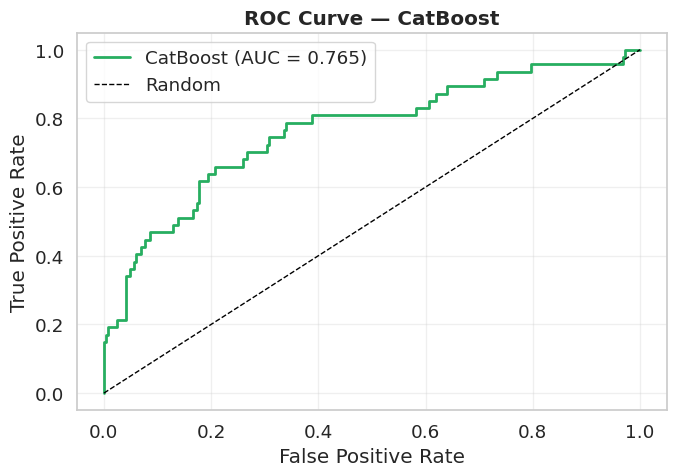

In [142]:
# ===== CATBOOST ROC CURVE =====
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
auc_cat = roc_auc_score(y_test, y_prob_cat)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_cat, tpr_cat, color='#27ae60', linewidth=2, label=f'CatBoost (AUC = {auc_cat:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC Curve — CatBoost', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Neural Network (Custom Class Weights)

We add a **Deep Neural Network** to our comparison. Key features:
- **Custom class weights** to handle the imbalanced dataset (same ratio as XGBoost's `scale_pos_weight`)
- **Dropout regularization** to prevent overfitting on this small dataset
- **Early stopping** to find the optimal number of epochs automatically
- Architecture: 128 → 64 → 32 → 1 (sigmoid)

In [143]:
# ===== NEURAL NETWORK WITH CUSTOM CLASS WEIGHTS =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set seed for reproducibility
tf.random.set_seed(RANDOM_STATE)

# ===== CALCULATE CLASS WEIGHTS =====
# Same logic as scale_pos_weight — give minority class more importance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weight_dict = {
    0: 1.0,
    1: neg_count / pos_count  # ~5.2x weight for attrition class
}
print(f"Class weights: {{0: {class_weight_dict[0]:.2f}, 1: {class_weight_dict[1]:.2f}}}")
print(f"→ Giving {class_weight_dict[1]:.1f}x more importance to 'Leave' samples")

# ===== BUILD THE NEURAL NETWORK =====
n_features = X_train_scaled.shape[1]

nn_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

# ===== TRAIN WITH EARLY STOPPING =====
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: 1.00, 1: 5.19}
→ Giving 5.2x more importance to 'Leave' samples


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7480 - loss: 1.3716 - val_accuracy: 0.6483 - val_loss: 0.6161
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7300 - loss: 1.0147 - val_accuracy: 0.6356 - val_loss: 0.6211
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - loss: 0.9461 - val_accuracy: 0.6695 - val_loss: 0.6066
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6920 - loss: 0.8580 - val_accuracy: 0.7119 - val_loss: 0.5791
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7356 - loss: 0.8679 - val_accuracy: 0.7288 - val_loss: 0.5572
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7359 - loss: 0.8137 - val_accuracy: 0.7415 - val_loss: 0.5332
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7592 - loss: 0.7590 - val_accuracy: 0.7669 - val_loss: 0.5029
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7876 - loss: 0.6980 - val_accuracy: 0.7754 - 

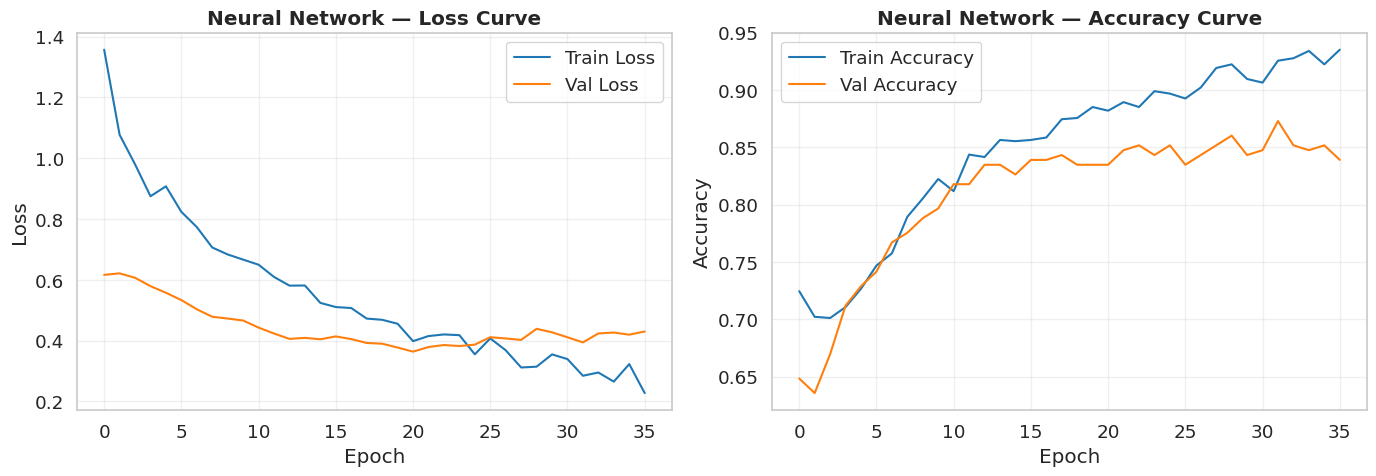

In [144]:
# ===== TRAINING CURVES =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Neural Network — Loss Curve', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Neural Network — Accuracy Curve', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [145]:
# ===== NEURAL NETWORK EVALUATION =====
y_prob_nn = nn_model.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Neural Network — Test Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_nn):.4f}")
print(f"F1 (Yes):  {f1_score(y_test, y_pred_nn):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_nn)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Neural Network — Test Results
Accuracy:  0.8061
ROC-AUC:   0.7370
F1 (Yes):  0.4571

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       247
           1       0.41      0.51      0.46        47

    accuracy                           0.81       294
   macro avg       0.66      0.69      0.67       294
weighted avg       0.82      0.81      0.81       294



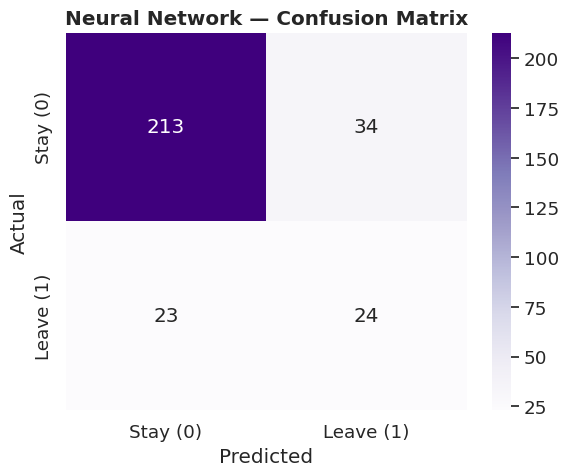

In [146]:
# ===== NEURAL NETWORK CONFUSION MATRIX =====
fig, ax = plt.subplots(figsize=(6, 5))
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Stay (0)', 'Leave (1)'],
            yticklabels=['Stay (0)', 'Leave (1)'])
ax.set_title('Neural Network — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

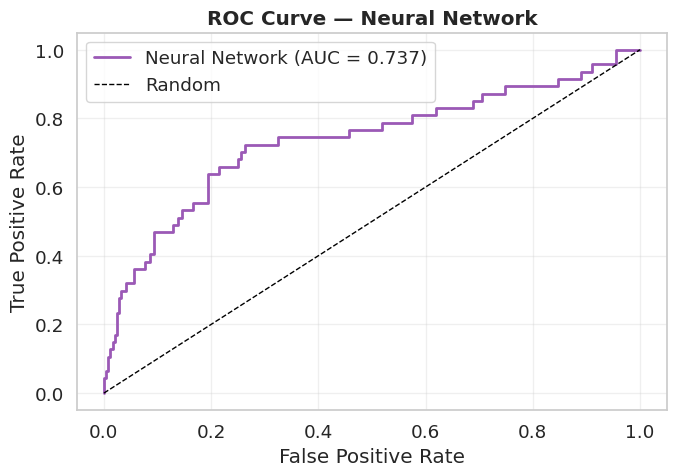

In [147]:
# ===== NEURAL NETWORK ROC CURVE =====
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_nn, tpr_nn, color='#9b59b6', linewidth=2, label=f'Neural Network (AUC = {auc_nn:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title('ROC Curve — Neural Network', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Model Comparison

Now we compare all three models on the **same chart** and create a summary table  
to determine the best model. We focus on **F1-Score** and **ROC-AUC** — not just accuracy.

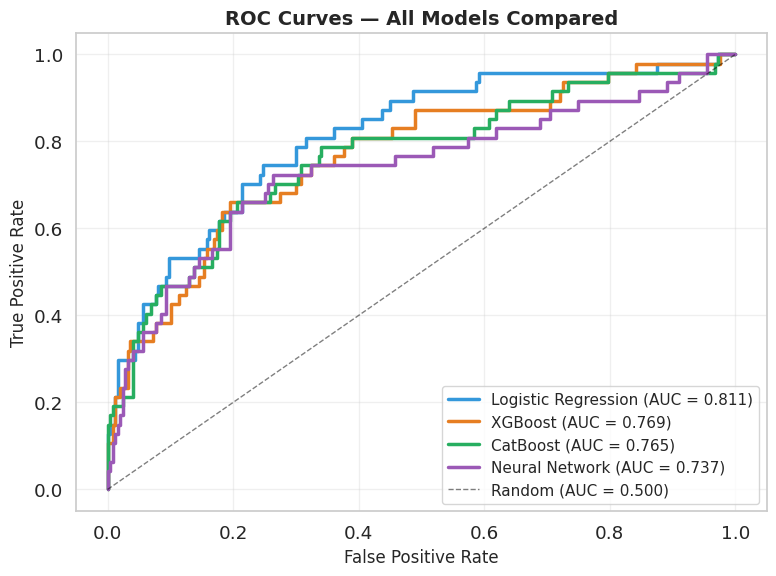

In [148]:
# ===== COMBINED ROC CURVE — ALL 4 MODELS =====
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
ax.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# XGBoost
ax.plot(fpr_xgb, tpr_xgb, color='#e67e22', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.3f})')

# CatBoost
ax.plot(fpr_cat, tpr_cat, color='#27ae60', linewidth=2.5,
        label=f'CatBoost (AUC = {auc_cat:.3f})')

# Neural Network
ax.plot(fpr_nn, tpr_nn, color='#9b59b6', linewidth=2.5,
        label=f'Neural Network (AUC = {auc_nn:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')

ax.set_title('ROC Curves — All Models Compared', fontweight='bold', fontsize=14)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [149]:
# ===== SUMMARY COMPARISON TABLE =====
from sklearn.metrics import precision_score, recall_score

results = []
models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'CatBoost': (y_pred_cat, y_prob_cat),
    'Neural Network': (y_pred_nn, y_prob_nn),
}

for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Attrition)': precision_score(y_test, y_pred),
        'Recall (Attrition)': recall_score(y_test, y_pred),
        'F1 (Attrition)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model')

# Format as percentages for readability
results_styled = results_df.style.format('{:.4f}').highlight_max(
    axis=0, color='lightgreen'
).set_caption('Model Comparison — Higher is Better (Green = Best)')

results_styled

,Accuracy,Precision (Attrition),Recall (Attrition),F1 (Attrition),ROC-AUC
Model,,,,,
Logistic Regression,0.7619,0.3614,0.6383,0.4615,0.8108
XGBoost,0.8469,0.5333,0.3404,0.4156,0.7686
CatBoost,0.8265,0.4583,0.4681,0.4632,0.7649
Neural Network,0.8061,0.4138,0.5106,0.4571,0.7370


In [150]:
# ===== PRINT FINAL COMPARISON =====
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON \u2014 Test Set Metrics")
print("=" * 70)
print(results_df.to_string())

# Cross-Validation Summary
print("\n" + "=" * 70)
print("CROSS-VALIDATION RESULTS (5-Fold Stratified \u2014 More Reliable!)")
print("=" * 70)
cv_summary = pd.DataFrame({
    'Logistic Regression': lr_cv_scores,
    'XGBoost (Tuned)': xgb_cv_scores,
    'CatBoost': cat_cv_scores
}).T
cv_summary.columns = ['CV Accuracy', 'CV F1', 'CV ROC-AUC']
print(cv_summary.to_string())
print("=" * 70)

best_f1_model = results_df['F1 (Attrition)'].idxmax()
best_auc_model = results_df['ROC-AUC'].idxmax()

print(f"\n\U0001f3c6 Best model by F1 Score:  {best_f1_model} ({results_df.loc[best_f1_model, 'F1 (Attrition)']:.4f})")
print(f"\U0001f3c6 Best model by ROC-AUC:   {best_auc_model} ({results_df.loc[best_auc_model, 'ROC-AUC']:.4f})")
print(f"\n\U0001f4ca Cross-validation confirms these results are stable, not a lucky split!")


FINAL MODEL COMPARISON — Test Set Metrics
                     Accuracy  Precision (Attrition)  Recall (Attrition)  F1 (Attrition)   ROC-AUC
Model                                                                                             
Logistic Regression  0.761905               0.361446            0.638298        0.461538  0.810750
XGBoost              0.846939               0.533333            0.340426        0.415584  0.768628
CatBoost             0.826531               0.458333            0.468085        0.463158  0.764924
Neural Network       0.806122               0.413793            0.510638        0.457143  0.737014

CROSS-VALIDATION RESULTS (5-Fold Stratified — More Reliable!)
                     CV Accuracy     CV F1  CV ROC-AUC
Logistic Regression     0.761021  0.497364    0.829583
XGBoost (Tuned)         0.865636  0.514667    0.807071
CatBoost                0.850317  0.518802    0.795028

🏆 Best model by F1 Score:  CatBoost (0.4632)
🏆 Best model by ROC-AUC:   Logisti

## Final Conclusion

### Why we don't judge by Accuracy alone:
- A dummy classifier gets ~84% accuracy by always predicting "No"
- **F1-Score** tells us how well we detect employees who actually leave
- **ROC-AUC** measures overall discriminative ability

### Model Selection Guidelines:
| If your priority is... | Use this model |
|---|---|
| **Catching as many leavers as possible** (high recall) | Model with highest Recall |
| **Balanced precision & recall** | Model with highest F1-Score |
| **Overall ranking ability** | Model with highest ROC-AUC |
| **Interpretability / explainability** | Logistic Regression |
| **Raw predictive power** | XGBoost or CatBoost |

### Business Recommendation:
For HR attrition prediction, **recall is often more important than precision** —  
it's better to flag an employee who might leave (false alarm) than to miss someone  
who actually leaves (missed detection). Use this to guide your model choice.



In [151]:
# ===== SAVE ALL TRAINED MODELS =====
import joblib
import os

# Create a directory for saved models
MODELS_DIR = 'saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Save XGBoost model ---
xgb_path = os.path.join(MODELS_DIR, 'xgboost_best_model.pkl')
joblib.dump(xgb_model, xgb_path)
print(f'XGBoost model saved to: {xgb_path}')

# --- Save CatBoost model ---
cat_path = os.path.join(MODELS_DIR, 'catboost_model.pkl')
joblib.dump(cat_model, cat_path)
print(f'CatBoost model saved to: {cat_path}')

# --- Save Neural Network model (Keras) ---
nn_path = os.path.join(MODELS_DIR, 'neural_network_model.h5')
nn_model.save(nn_path)
print(f'Neural Network model saved to: {nn_path}')

print('\n All models saved successfully!')
print(f'Models directory: {os.path.abspath(MODELS_DIR)}')


XGBoost model saved to: saved_models/xgboost_best_model.pkl
CatBoost model saved to: saved_models/catboost_model.pkl
Neural Network model saved to: saved_models/neural_network_model.h5

 All models saved successfully!
Models directory: /kaggle/working/saved_models


In [152]:
!pip install mlflow

In [154]:
# ===== MLFLOW MODEL TRACKING & EVALUATION =====
import mlflow
import mlflow.sklearn
import joblib
import os
import pandas as pd
from mlflow.models import infer_signature
import logging
logging.getLogger('mlflow').setLevel(logging.ERROR)


# Load the saved XGBoost model
xgb_model_loaded = joblib.load(os.path.join('saved_models', 'xgboost_best_model.pkl'))

# Use REAL feature names from training data (fixes feature_names mismatch)
feature_names = list(X_train.columns)

# Create evaluation DataFrame with correct column names
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
eval_data = X_test_df.copy()
eval_data['label'] = y_test.values

with mlflow.start_run():
    # Log model with signature
    signature = infer_signature(X_test_df, xgb_model_loaded.predict(X_test_df))
    model_info = mlflow.sklearn.log_model(xgb_model_loaded, name='xgboost_best_model', signature=signature)

    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets='label',
        model_type='classifier',
    )

    print(f"Accuracy: {result.metrics['accuracy_score']:.3f}")
    print(f"F1 Score: {result.metrics['f1_score']:.3f}")
    print(f"ROC AUC: {result.metrics['roc_auc']:.3f}")


Accuracy: 0.847
F1 Score: 0.416
ROC AUC: 0.769


In [157]:
# ===== MLFLOW MODEL TRACKING & EVALUATION (CatBoost) =====
import mlflow
import mlflow.catboost
import joblib
import os
import pandas as pd
from mlflow.models import infer_signature
import logging
logging.getLogger('mlflow').setLevel(logging.ERROR)

# Load the saved CatBoost model
cat_model_loaded = joblib.load(os.path.join('saved_models', 'catboost_model.pkl'))

# Use REAL feature names from training data
feature_names = list(X_train.columns)

# Create evaluation DataFrame with correct column names
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
eval_data = X_test_df.copy()
eval_data['label'] = y_test.values

with mlflow.start_run():
    # Log model with signature
    signature = infer_signature(X_test_df, cat_model_loaded.predict(X_test_df))
    model_info = mlflow.catboost.log_model(cat_model_loaded, artifact_path='catboost_model', signature=signature)

    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets='label',
        model_type='classifier',
    )

    print(f"Accuracy: {result.metrics['accuracy_score']:.3f}")
    print(f"F1 Score: {result.metrics['f1_score']:.3f}")
    print(f"ROC AUC: {result.metrics['roc_auc']:.3f}")



Accuracy: 0.827
F1 Score: 0.463
ROC AUC: 0.765
